In [1]:
import os, sys, pickle
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from multiprocessing import Pool

sys.path.insert(0, str(Path('../').resolve()))

BASE_DIR = Path('../../GraPPI_data/curated_db')

FOLDERS = {
    'pos_sthg_8A':        'SSL (pos)',
    'preppi_sthg_8A':     'Negative (PrePPI)',
    'random_mut_sthg_8A': 'Negative (random mut)',
    'swapped_abag_sthg_8A': 'Negative (swapped Ab/Ag)',
    'unmut_sthg_8A':      'Binding affinity (unmut)',
    'mutant_sthg_8A':     'Binding affinity (mutant)',
}


In [2]:
def _get_sizes(pkl_path):
    try:
        with open(pkl_path, 'rb') as f:
            obj = pickle.load(f)
        g = obj.protein_graph
        n_rec = g['receptor'].x.shape[0]
        n_lig = g['ligand'].x.shape[0]
        return (n_rec, n_lig)
    except Exception:
        return None


def load_sizes(folder_name, n_workers=8):
    pkls = sorted((BASE_DIR / folder_name).glob('*.pkl'))
    with Pool(n_workers) as pool:
        results = pool.map(_get_sizes, [str(p) for p in pkls])
    return [r for r in results if r is not None]


print('Loading residue counts (this may take ~1 min)...')
all_sizes = {}
for folder in FOLDERS:
    print(f'  {folder}... ', end='', flush=True)
    all_sizes[folder] = load_sizes(folder)
    sizes_total = [r + l for r, l in all_sizes[folder]]
    print(f'{len(sizes_total)} samples | total residues: '
          f'min={min(sizes_total)}, median={int(np.median(sizes_total))}, max={max(sizes_total)}')
print('Done.')


Loading residue counts (this may take ~1 min)...
  pos_sthg_8A... 11593 samples | total residues: min=21, median=373, max=4766
  preppi_sthg_8A... 15000 samples | total residues: min=82, median=252, max=1475
  random_mut_sthg_8A... 8555 samples | total residues: min=21, median=347, max=4210
  swapped_abag_sthg_8A... 272 samples | total residues: min=292, median=589, max=827
  unmut_sthg_8A... 2903 samples | total residues: min=42, median=439, max=3426
  mutant_sthg_8A... 6577 samples | total residues: min=57, median=409, max=3397
Done.


In [3]:
# Summary table: per-folder stats including per-protein sizes for padding planning
print(f"{'Folder':<30} {'N':>6}  {'Complex (rec+lig)':^30}  {'Max-protein (max(rec,lig))':^30}")
print(f"{'':30} {'':6}  {'min':>6} {'med':>6} {'mean':>7} {'max':>6}  {'min':>6} {'med':>6} {'mean':>7} {'max':>6}")
print('-' * 100)
for folder, label in FOLDERS.items():
    pairs = all_sizes[folder]
    total  = [r + l for r, l in pairs]
    maxp   = [max(r, l) for r, l in pairs]
    pct_over_1000 = 100 * sum(m > 1000 for m in maxp) / len(maxp)
    print(f"{label:<30} {len(pairs):>6}  "
          f"{min(total):>6} {int(np.median(total)):>6} {np.mean(total):>7.0f} {max(total):>6}  "
          f"{min(maxp):>6} {int(np.median(maxp)):>6} {np.mean(maxp):>7.0f} {max(maxp):>6}  "
          f"(>{1000}: {pct_over_1000:.1f}%)")


Folder                              N        Complex (rec+lig)           Max-protein (max(rec,lig))  
                                          min    med    mean    max     min    med    mean    max
----------------------------------------------------------------------------------------------------
SSL (pos)                       11593      21    373     451   4766      11    245     304   4529  (>1000: 2.0%)
Negative (PrePPI)               15000      82    252     299   1475      45    144     197   1258  (>1000: 0.2%)
Negative (random mut)            8555      21    347     419   4210      11    225     276   3905  (>1000: 1.5%)
Negative (swapped Ab/Ag)          272     292    589     596    827     223    431     419    438  (>1000: 0.0%)
Binding affinity (unmut)         2903      42    439     492   3426      21    317     351   3302  (>1000: 2.0%)
Binding affinity (mutant)        6577      57    409     473   3397      52    262     318   3119  (>1000: 2.0%)


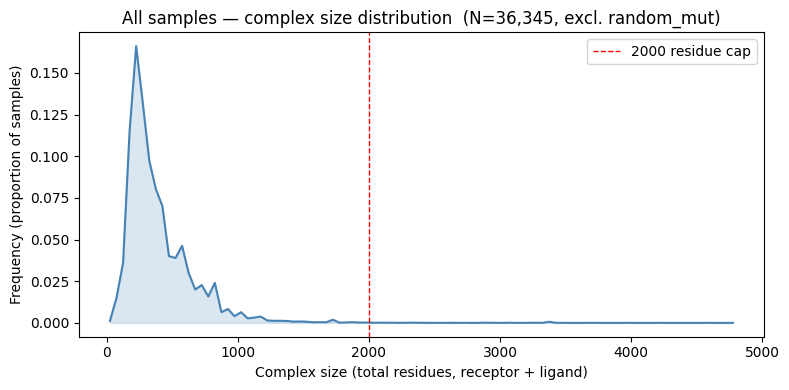

In [ ]:
# Plot 1: combined histogram of all samples excluding random_mut
exclude = {'random_mut_sthg_8A'}
combined = []
for folder in FOLDERS:
    if folder not in exclude:
        combined.extend(r + l for r, l in all_sizes[folder])

bins = np.arange(0, max(combined) + 50, 50)
counts, edges = np.histogram(combined, bins=bins)
freq = counts / len(combined)
centers = (edges[:-1] + edges[1:]) / 2

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(centers, freq, color='steelblue', linewidth=1.5)
ax.fill_between(centers, freq, alpha=0.2, color='steelblue')
ax.set_xlabel('Complex size (total residues, receptor + ligand)')
ax.set_ylabel('Frequency (proportion of samples)')
ax.set_title(f'All samples — complex size distribution  (N={len(combined):,}, excl. random_mut)')
ax.axvline(2000, color='red', linestyle='--', linewidth=1, label='2000 residue cap')
ax.legend()
plt.tight_layout()
#plt.savefig('../Figures/dataset_complex_size_all.pdf', bbox_inches='tight')


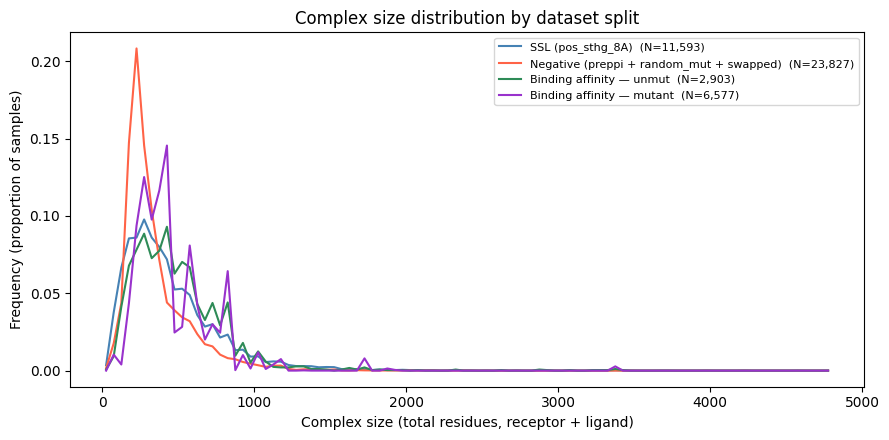

In [ ]:
# Plot 2: overlaid histogram curves per dataset category
groups = {
    'SSL (pos_sthg_8A)':     [r + l for r, l in all_sizes['pos_sthg_8A']],
    'Negative (preppi + random_mut + swapped)': [
        r + l for folder in ('preppi_sthg_8A', 'random_mut_sthg_8A', 'swapped_abag_sthg_8A')
        for r, l in all_sizes[folder]
    ],
    'Binding affinity — unmut': [r + l for r, l in all_sizes['unmut_sthg_8A']],
    'Binding affinity — mutant': [r + l for r, l in all_sizes['mutant_sthg_8A']],
}
colors = ['steelblue', 'tomato', 'seagreen', 'darkorchid']

# shared bin edges across all groups for comparability
all_vals = [v for vals in groups.values() for v in vals]
bins = np.arange(0, max(all_vals) + 50, 50)
centers = (bins[:-1] + bins[1:]) / 2

fig, ax = plt.subplots(figsize=(9, 4.5))
for (label, vals), color in zip(groups.items(), colors):
    counts, _ = np.histogram(vals, bins=bins)
    freq = counts / len(vals)
    ax.plot(centers, freq, label=f'{label}  (N={len(vals):,})', color=color, linewidth=1.5)

ax.set_xlabel('Complex size (total residues, receptor + ligand)')
ax.set_ylabel('Frequency (proportion of samples)')
ax.set_title('Complex size distribution by dataset split')
ax.legend(fontsize=8)
plt.tight_layout()
#plt.savefig('../Figures/dataset_complex_size_by_split.pdf', bbox_inches='tight')
